In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "",
    connect_args={"sslmode": "require"}
)

In [2]:
df = pd.read_sql(
    'SELECT * FROM "Water_For_Productions";',
    engine
)
df

,Id,Year,Total,Fresh_water_tech,Fresh_drinking,Total_recirculation_water,Recurculation_fresh_water_added,Reused_water_afterPurifying,Reused_water_afterCooling
0,1,2009,4398217.0,4189959.0,189614.0,3775.0,627.0,6415.0,101.0
1,2,2010,6251678.0,5768006.0,467718.0,26992.0,11038.0,0.0,0.0
2,3,2011,4953364.0,4798605.0,126976.0,29413.0,2033.0,181.0,225.0
3,4,2012,4923165.0,4368666.0,63481.0,551425.0,13.0,2000.0,1158.0
4,5,2013,2437998.0,2101022.0,324282.0,12552.0,1075.0,1065.0,152.0
5,6,2014,3366146.0,3345818.0,8321.0,11957.0,30.0,0.0,50.0
6,7,2015,4275252.0,4255626.0,10230.0,14634.0,5572.0,126.0,199.0
7,8,2016,3698687.0,3682201.0,7954.0,23.0,23.0,13.0,4.0
8,9,2017,1295489.0,1282780.0,3959.0,18717.0,18668.0,8701.0,1.0
9,10,2018,2259721.0,2204429.0,23146.0,24944.0,17491.0,7200.0,0.0


In [12]:
df = df.drop(columns=["Id"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             16 non-null     int64  
 1   Total                            16 non-null     float64
 2   Fresh_water_tech                 16 non-null     float64
 3   Fresh_drinking                   16 non-null     float64
 4   Total_recirculation_water        16 non-null     float64
 5   Recurculation_fresh_water_added  16 non-null     float64
 6   Reused_water_afterPurifying      16 non-null     float64
 7   Reused_water_afterCooling        16 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 1.1 KB


In [13]:
columns_to_model = df.columns.drop("Year")
future_years = pd.DataFrame({"Year": [2025, 2026, 2027, 2028, 2029]})

In [14]:
import os

model_dir = "../models/Industrial_water_use_poly"
os.makedirs(model_dir, exist_ok=True)

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import joblib

forecasts = {}

for col in columns_to_model:
    X = df[["Year"]].values
    y = df[col].values

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("lr", LinearRegression())
    ])

    model.fit(X, y)

    preds = model.predict(future_years[["Year"]].values)
    forecasts[col] = preds

    joblib.dump(
        model,
        f"{model_dir}/{col}_poly2.pkl"
    )

In [16]:
forecast_df = pd.DataFrame(forecasts, index=future_years["Year"])
forecast_df

,Total,Fresh_water_tech,Fresh_drinking,Total_recirculation_water,Recurculation_fresh_water_added,Reused_water_afterPurifying,Reused_water_afterCooling
Year,,,,,,,
2025,4.734160e+06,4.617573e+06,40624.092438,143846.655273,26205.258789,9227.288223,3695.156898
2026,6.314509e+06,6.114585e+06,60302.013794,234213.466797,22919.052551,8813.344742,5100.162445
2027,8.297174e+06,7.990076e+06,83368.402527,351096.983887,17766.766663,7906.300934,6802.797409
2028,1.071780e+07,1.027763e+07,109676.767151,497275.653320,10525.907349,6438.107834,8829.641922
2029,1.361203e+07,1.301084e+07,139080.615845,675527.919434,973.981018,4340.716476,11207.276009


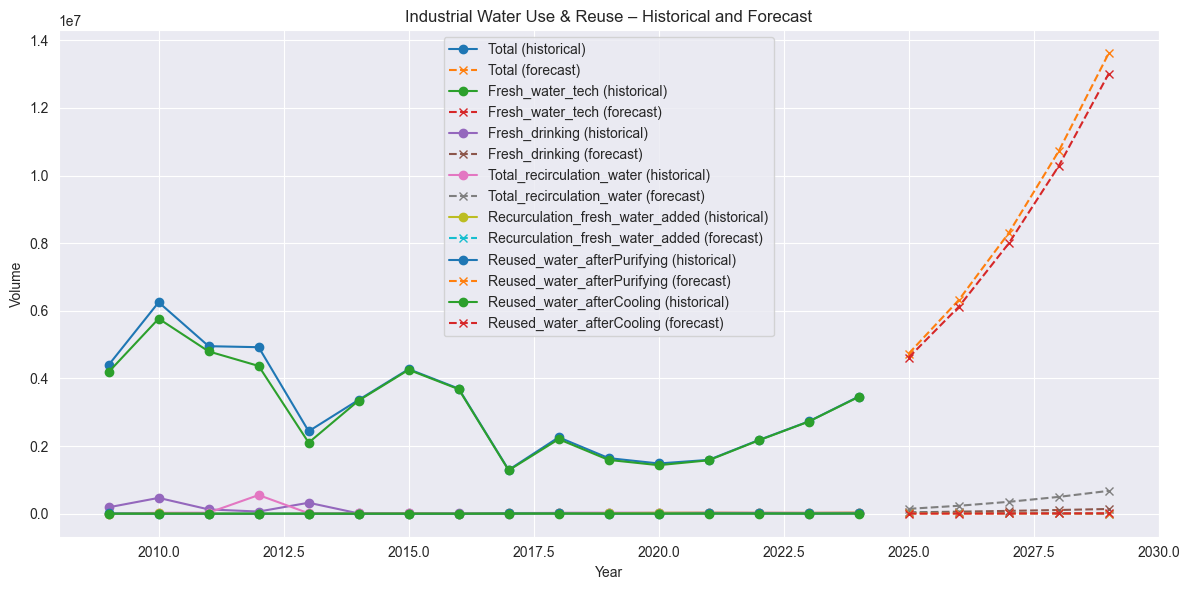

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for col in columns_to_model:
    plt.plot(df["Year"], df[col], marker="o", label=f"{col} (historical)")
    plt.plot(
        future_years["Year"],
        forecast_df[col],
        marker="x",
        linestyle="--",
        label=f"{col} (forecast)"
    )

plt.title("Industrial Water Use & Reuse – Historical and Forecast")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()